In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\RAAID FARHAN\Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
import numpy as np
age = df["Age"].values

print("Average Age:", np.mean(age))
print("Maximum Age:", np.max(age))
print("Minimum Age:", np.min(age))
print("Median Age:", np.median(age))
print("Standard Deviation:", np.std(age))

Average Age: 38.85
Maximum Age: 70
Minimum Age: 18
Median Age: 36.0
Standard Deviation: 13.934041050606963


In [9]:
income = df["Annual Income (k$)"].values

print("Average Income:", np.mean(income))
print("Highest Income:", np.max(income))
print("Lowest Income:", np.min(income))

Average Income: 60.56
Highest Income: 137
Lowest Income: 15


In [10]:
spending = df["Spending Score (1-100)"].values

print("Average Spending Score:", np.mean(spending))

Average Spending Score: 50.2


In [11]:
customer_array = df.to_numpy()

print(customer_array)

[[1 'Male' 19 15 39]
 [2 'Male' 21 15 81]
 [3 'Female' 20 16 6]
 [4 'Female' 23 16 77]
 [5 'Female' 31 17 40]
 [6 'Female' 22 17 76]
 [7 'Female' 35 18 6]
 [8 'Female' 23 18 94]
 [9 'Male' 64 19 3]
 [10 'Female' 30 19 72]
 [11 'Male' 67 19 14]
 [12 'Female' 35 19 99]
 [13 'Female' 58 20 15]
 [14 'Female' 24 20 77]
 [15 'Male' 37 20 13]
 [16 'Male' 22 20 79]
 [17 'Female' 35 21 35]
 [18 'Male' 20 21 66]
 [19 'Male' 52 23 29]
 [20 'Female' 35 23 98]
 [21 'Male' 35 24 35]
 [22 'Male' 25 24 73]
 [23 'Female' 46 25 5]
 [24 'Male' 31 25 73]
 [25 'Female' 54 28 14]
 [26 'Male' 29 28 82]
 [27 'Female' 45 28 32]
 [28 'Male' 35 28 61]
 [29 'Female' 40 29 31]
 [30 'Female' 23 29 87]
 [31 'Male' 60 30 4]
 [32 'Female' 21 30 73]
 [33 'Male' 53 33 4]
 [34 'Male' 18 33 92]
 [35 'Female' 49 33 14]
 [36 'Female' 21 33 81]
 [37 'Female' 42 34 17]
 [38 'Female' 30 34 73]
 [39 'Female' 36 37 26]
 [40 'Female' 20 37 75]
 [41 'Female' 65 38 35]
 [42 'Male' 24 38 92]
 [43 'Male' 48 39 36]
 [44 'Female' 31 39

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create KMeans model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit model and assign clusters
df["Cluster"] = kmeans.fit_predict(X_scaled)

# NumPy
unique_clusters = np.unique(df["Cluster"])

print("Clusters:", unique_clusters)
print("Number of Clusters:", len(unique_clusters))

Clusters: [0 1 2 3 4]
Number of Clusters: 5


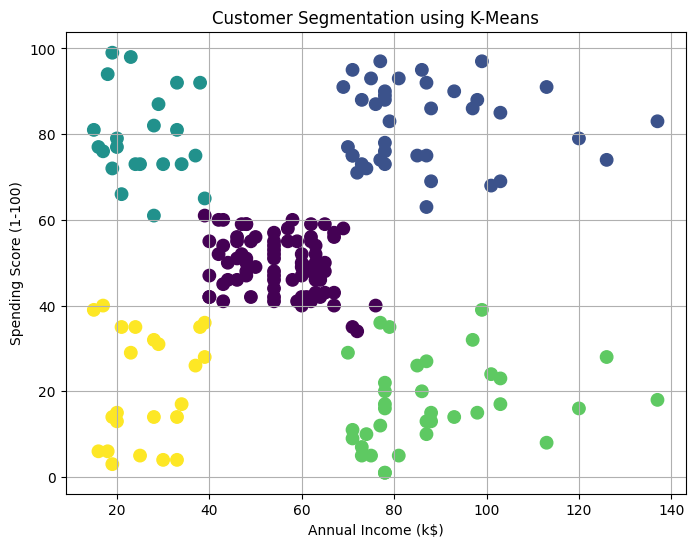

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True)

plt.show()

In [16]:
df["Cluster"].value_counts()

cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


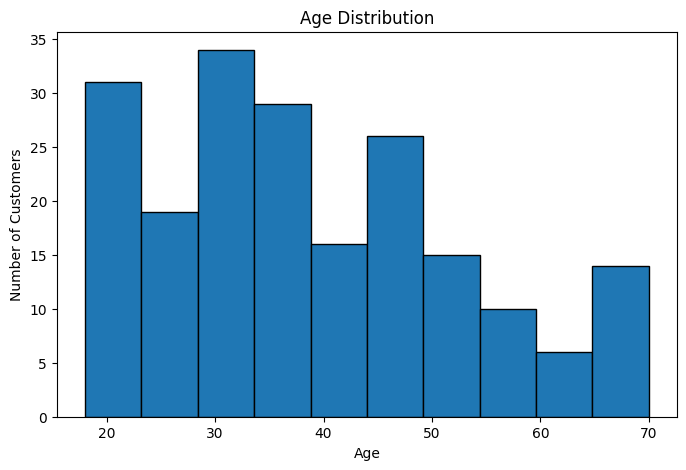

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

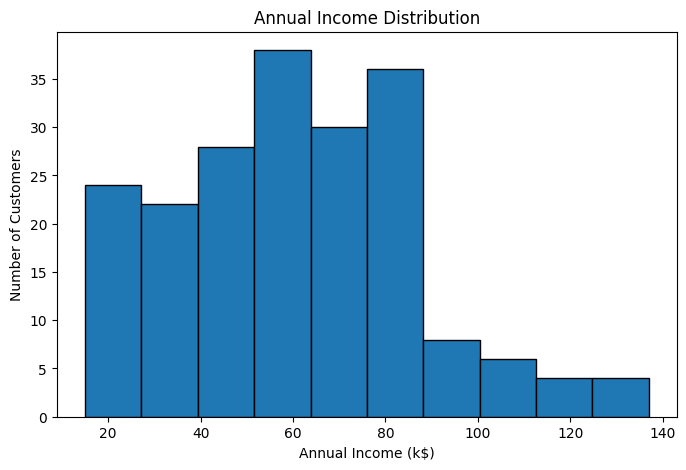

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Annual Income (k$)"], bins=10, edgecolor="black")

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

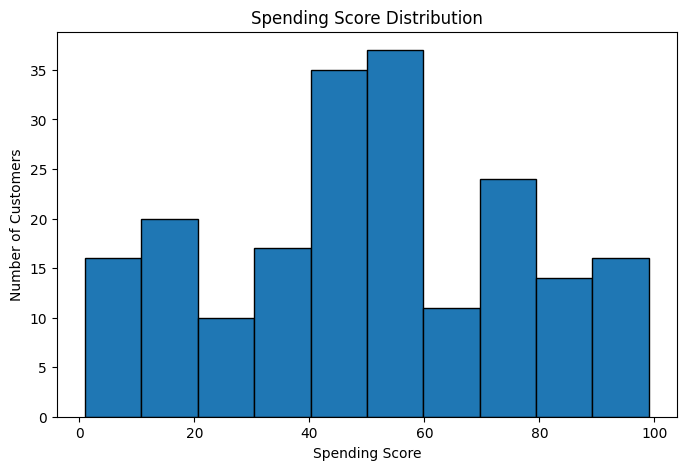

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["Spending Score (1-100)"], bins=10, edgecolor="black")

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

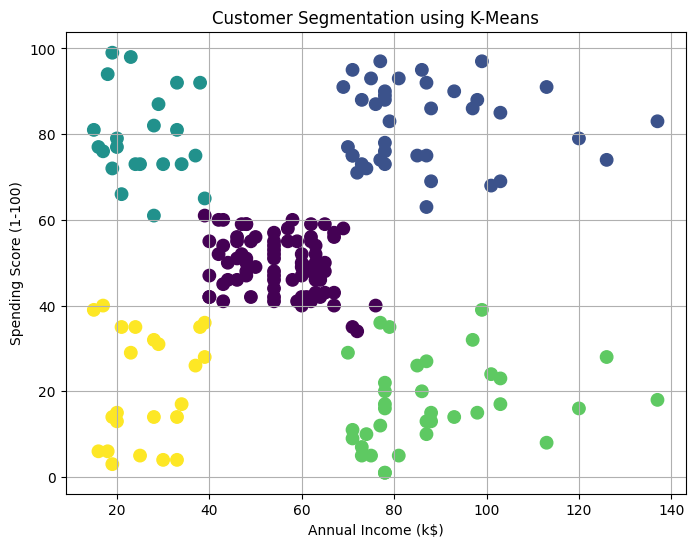

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True)

plt.show()

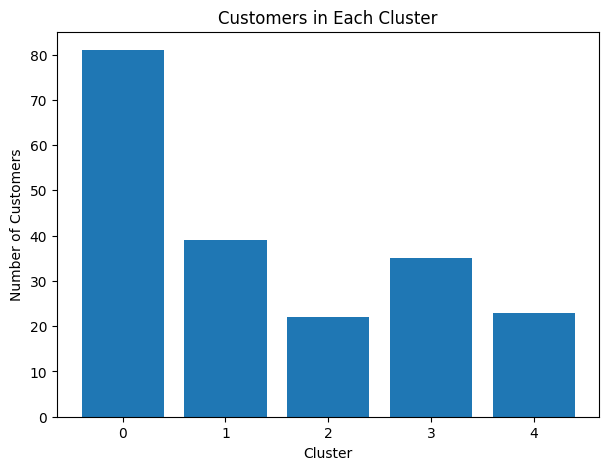

In [21]:
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.bar(cluster_counts.index, cluster_counts.values)

plt.title("Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [26]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)
    print(wcss)

[399.99999999999994]
[399.99999999999994, 269.69101219276394]
[399.99999999999994, 269.69101219276394, 157.70400815035947]
[399.99999999999994, 269.69101219276394, 157.70400815035947, 108.92131661364357]
[399.99999999999994, 269.69101219276394, 157.70400815035947, 108.92131661364357, 65.56840815571681]
[399.99999999999994, 269.69101219276394, 157.70400815035947, 108.92131661364357, 65.56840815571681, 55.057348270386]
[399.99999999999994, 269.69101219276394, 157.70400815035947, 108.92131661364357, 65.56840815571681, 55.057348270386, 44.86475569922557]
[399.99999999999994, 269.69101219276394, 157.70400815035947, 108.92131661364357, 65.56840815571681, 55.057348270386, 44.86475569922557, 37.228187677585886]
[399.99999999999994, 269.69101219276394, 157.70400815035947, 108.92131661364357, 65.56840815571681, 55.057348270386, 44.86475569922557, 37.228187677585886, 32.39226763033116]
[399.99999999999994, 269.69101219276394, 157.70400815035947, 108.92131661364357, 65.56840815571681, 55.057348270

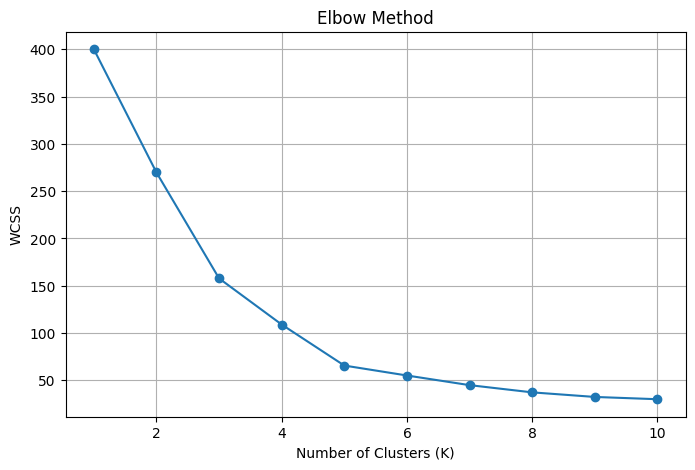

In [27]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [28]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

print("Cluster Centers:")
print(centers)

Cluster Centers:
[[ 24.58333333   9.58333333]
 [ 63.72093023  46.1627907 ]
 [ 78.55172414  82.17241379]
 [109.7         22.        ]
 [ 24.46666667  74.6       ]
 [109.7         82.        ]
 [ 80.18181818  12.68181818]
 [ 30.          34.61538462]
 [ 48.1         52.675     ]
 [ 26.66666667  93.66666667]]


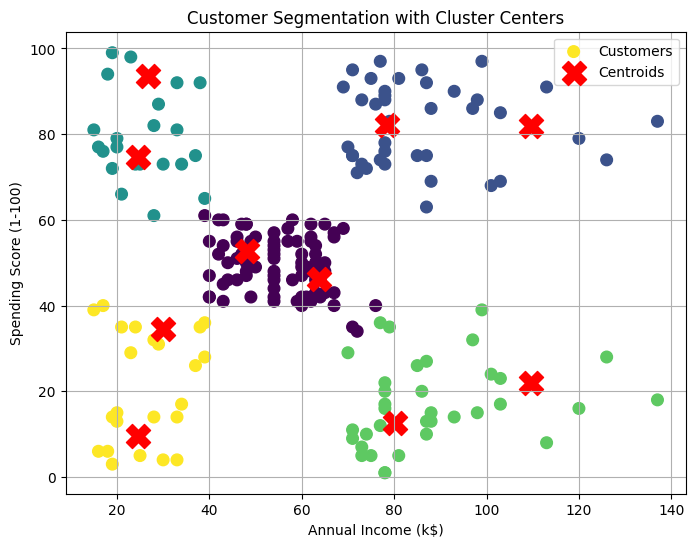

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=70,
    label="Customers"
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=300,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation with Cluster Centers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043
